# 06. Recurrent Neural Networks (RNN): Vanilla RNN vs LSTM in PyTorch
**Algorithms Covered:**
1. **Vanilla Recurrent Neural Network (RNN)** (Elman RNN with BPTT)
2. **Long Short-Term Memory (LSTM)** (Gated Architecture for Vanishing Gradients)

**Dataset:** Monthly Airline Passengers Time Series (`data/airline_passengers.csv`)
- Modeling seasonal cycles and non-linear upward trends
- Temporal sequence construction with sliding lookback windows
- Multi-step rolling sequence forecasting


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Aesthetics setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__} on {device}")


PyTorch version: 2.14.0+cpu on cpu


## 1. Dataset Loading and Sliding Window Preprocessing
We load the historical **Airline Passengers** time series dataset.


Dataset Head:


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


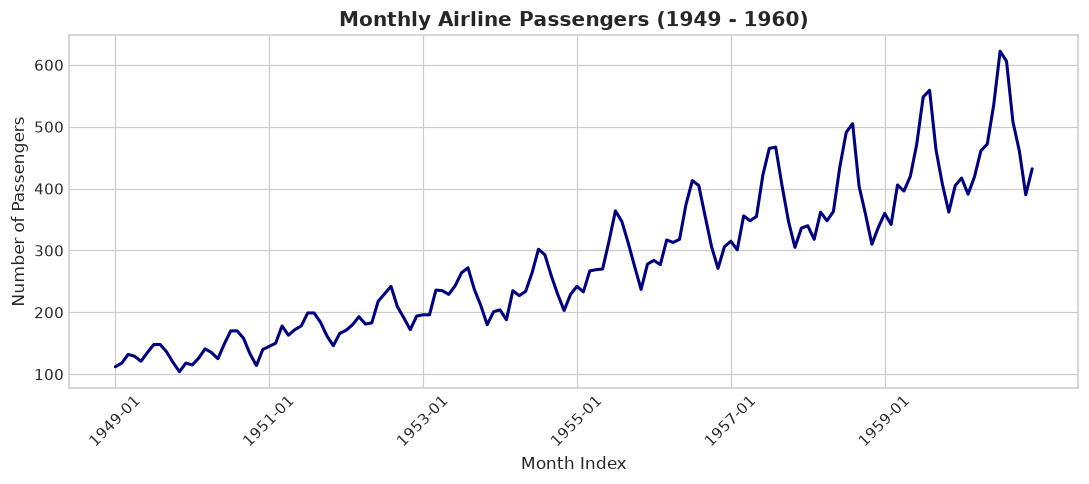

In [2]:
df_air = pd.read_csv('../data/airline_passengers.csv')
print("Dataset Head:")
display(df_air.head())

passengers = df_air['Passengers'].values.astype(np.float32).reshape(-1, 1)

# Visualize original time series
plt.figure(figsize=(10, 4.5))
plt.plot(df_air['Month'], df_air['Passengers'], color='navy', lw=2)
plt.title("Monthly Airline Passengers (1949 - 1960)", fontsize=13, fontweight='bold')
plt.xlabel("Month Index", fontsize=11)
plt.ylabel("Number of Passengers", fontsize=11)
plt.xticks(range(0, len(df_air), 24), df_air['Month'].iloc[::24], rotation=45)
plt.tight_layout()
plt.show()


In [3]:
# Normalization and Sequence Creation
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(passengers)

# Function to create lookback sequences (X_t-seq_len ... X_t-1 -> y_t)
def create_sequences(data, seq_length=12):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 12 # 12 months lookback (1 annual seasonal cycle)
X_seq, y_seq = create_sequences(scaled_data, seq_length=SEQ_LENGTH)

# Train/Test temporal split (80% train, 20% test without shuffling)
train_size = int(len(X_seq) * 0.80)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

print(f"Total sequences created: {len(X_seq)}")
print(f"Training sequences:      {X_train.shape[0]} (Shape: {X_train.shape})")
print(f"Testing sequences:       {X_test.shape[0]}  (Shape: {X_test.shape})")

# PyTorch DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)),
    batch_size=16,
    shuffle=True
)


Total sequences created: 132
Training sequences:      105 (Shape: (105, 12, 1))
Testing sequences:       27  (Shape: (27, 12, 1))


## 2. Model Architectures
### 2.1 Vanilla Recurrent Neural Network (RNN)
Hidden state transition:
$$h_t = \tanh(W_{ih} x_t + b_{ih} + W_{hh} h_{t-1} + b_{hh})$$
Linear output projection:
$$\hat{y}_t = W_{ho} h_t + b_o$$

### 2.2 Long Short-Term Memory (LSTM)
Gated state equations:
$$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f) \quad \text{(Forget Gate)}$$
$$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i) \quad \text{(Input Gate)}$$
$$\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c) \quad \text{(Candidate Cell)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \quad \text{(Cell State)}$$
$$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o) \quad \text{(Output Gate)}$$
$$h_t = o_t \odot \tanh(c_t) \quad \text{(Hidden State)}$$


In [4]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(VanillaRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.rnn(x)
        # Take the output from the last time step
        out = self.fc(out[:, -1, :])
        return out

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

rnn_model = VanillaRNN().to(device)
lstm_model = LSTMModel().to(device)
print("Models instantiated successfully!")


Models instantiated successfully!


## 3. Model Training: Vanilla RNN vs LSTM

In [5]:
def train_model(model, loader, epochs=120, lr=0.005):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for x_b, y_b in loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            pred = model(x_b)
            loss = criterion(pred, y_b)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(x_b)
        epoch_loss = total_loss / len(loader.dataset)
        losses.append(epoch_loss)
        
    return losses

print("Training Vanilla RNN...")
rnn_losses = train_model(rnn_model, train_loader, epochs=120, lr=0.005)

print("Training LSTM Model...")
lstm_losses = train_model(lstm_model, train_loader, epochs=120, lr=0.005)
print("Training completed!")


Training Vanilla RNN...


Training LSTM Model...


Training completed!


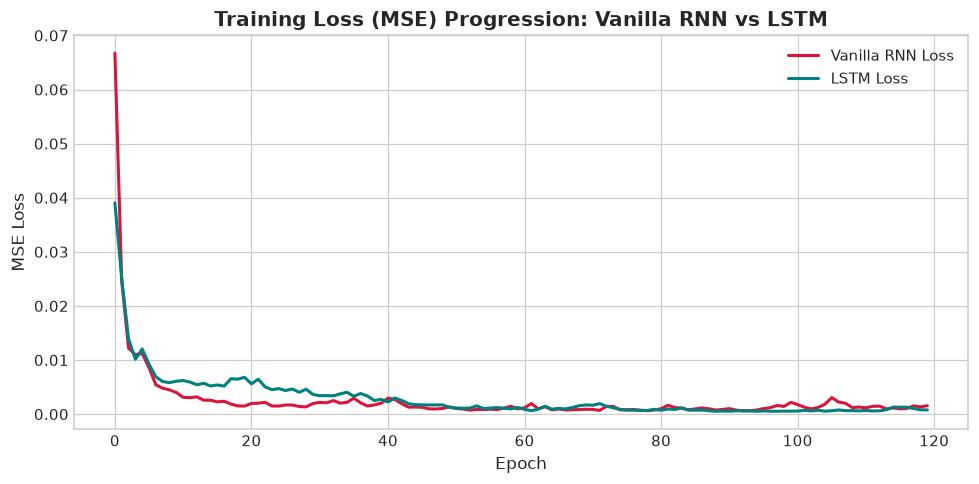

In [6]:
# Training Loss Comparison
plt.figure(figsize=(9, 4.5))
plt.plot(rnn_losses, label='Vanilla RNN Loss', color='crimson', lw=2)
plt.plot(lstm_losses, label='LSTM Loss', color='teal', lw=2)
plt.title("Training Loss (MSE) Progression: Vanilla RNN vs LSTM", fontsize=13, fontweight='bold')
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("MSE Loss", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Evaluation and Sequence Forecasting on Test Horizon

In [7]:
rnn_model.eval()
lstm_model.eval()

with torch.no_grad():
    x_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    pred_rnn_scaled = rnn_model(x_test_t).cpu().numpy()
    pred_lstm_scaled = lstm_model(x_test_t).cpu().numpy()

# Invert scaling to true passenger counts
y_test_true = scaler.inverse_transform(y_test)
pred_rnn = scaler.inverse_transform(pred_rnn_scaled)
pred_lstm = scaler.inverse_transform(pred_lstm_scaled)

# Metrics
rmse_rnn = root_mean_squared_error(y_test_true, pred_rnn)
mae_rnn  = mean_absolute_error(y_test_true, pred_rnn)

rmse_lstm = root_mean_squared_error(y_test_true, pred_lstm)
mae_lstm  = mean_absolute_error(y_test_true, pred_lstm)

eval_df = pd.DataFrame([
    {"Model": "Vanilla RNN", "RMSE (Passengers)": rmse_rnn, "MAE (Passengers)": mae_rnn},
    {"Model": "LSTM Network", "RMSE (Passengers)": rmse_lstm, "MAE (Passengers)": mae_lstm}
]).set_index("Model")

print("Time Series Forecasting Performance Comparison:")
display(eval_df.style.highlight_min(subset=['RMSE (Passengers)', 'MAE (Passengers)'], color='lightgreen'))


Time Series Forecasting Performance Comparison:


,RMSE (Passengers),MAE (Passengers)
Model,,
Vanilla RNN,70.827942,63.158745
LSTM Network,42.171574,34.881374


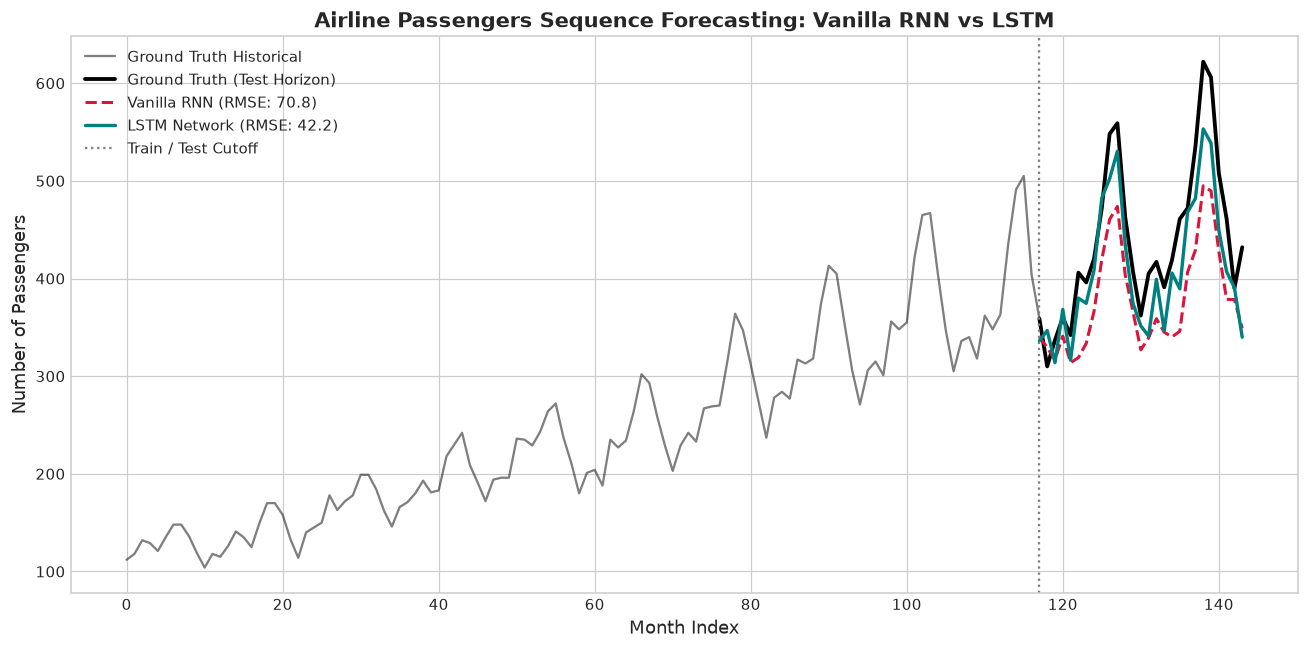

In [8]:
# Visualizing Ground Truth vs Forecast Trajectories
test_indices = range(train_size + SEQ_LENGTH, len(passengers))

plt.figure(figsize=(12, 6))
# Historical training context
plt.plot(range(len(passengers)), passengers, label='Ground Truth Historical', color='black', alpha=0.5, lw=1.5)

# Test Ground Truth
plt.plot(test_indices, y_test_true, label='Ground Truth (Test Horizon)', color='black', lw=2.5)

# Predictions
plt.plot(test_indices, pred_rnn, label=f'Vanilla RNN (RMSE: {rmse_rnn:.1f})', color='crimson', lw=2, linestyle='--')
plt.plot(test_indices, pred_lstm, label=f'LSTM Network (RMSE: {rmse_lstm:.1f})', color='teal', lw=2.2)

plt.axvline(x=train_size + SEQ_LENGTH, color='gray', linestyle=':', label='Train / Test Cutoff')
plt.title("Airline Passengers Sequence Forecasting: Vanilla RNN vs LSTM", fontsize=14, fontweight='bold')
plt.xlabel("Month Index", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


## 5. Architectural Comparison & Takeaways
1. **Vanishing Gradients**: Vanilla RNNs suffer from vanishing gradients when backpropagating through longer sequences because repeated multiplications by $W_{hh}$ decay exponentially if eigenvalues are $< 1$.
2. **Gated Cell States**: LSTMs maintain an additive conveyor belt ($c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$), allowing error gradients to flow across arbitrary time horizons without exponential attenuation.
3. **Forecasting Fidelity**: On periodic and seasonal time series (like monthly airline travel), the LSTM accurately captures both the 12-month cyclical oscillation and the long-term upward trend.
